In [ ]:
# Adaptive-K SGC on Reddit

!pip install torch_geometric -q
!pip install scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.0 MB/s eta 0:00:00


In [ ]:
# 1. Imports and Setup

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import f1_score

from torch_geometric.datasets import Reddit
from torch_geometric.nn.conv.gcn_conv import gcn_norm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

Device: cuda


In [ ]:
# 2. Load Reddit Dataset

dataset = Reddit(root="/content/Reddit")
data = dataset[0].to(device)

num_features = dataset.num_features
num_classes = dataset.num_classes

print(dataset)
print(data)
print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.edge_index.size(1))
print("Number of features:", num_features)
print("Number of classes:", num_classes)
print("Train nodes:", int(data.train_mask.sum()))
print("Val nodes:", int(data.val_mask.sum()))
print("Test nodes:", int(data.test_mask.sum()))

Extracting /content/Reddit/raw/reddit.zip
Processing...
Done!


Reddit()
Data(x=[232965, 602], edge_index=[2, 114615892], y=[232965], train_mask=[232965], val_mask=[232965], test_mask=[232965])
Number of nodes: 232965
Number of edges: 114615892
Number of features: 602
Number of classes: 41
Train nodes: 153431
Val nodes: 23831
Test nodes: 55703


In [ ]:
# 3. Precompute Multi-hop Features
# X_adaptive = alpha_0 X + alpha_1 S X + ... + alpha_K S^K X

def precompute_multi_hop_features(data, K_max=4):
    x = data.x.float()
    edge_index = data.edge_index

    edge_index_norm, edge_weight_norm = gcn_norm(
        edge_index=edge_index,
        edge_weight=None,
        num_nodes=data.num_nodes,
        add_self_loops=True,
        dtype=x.dtype
    )

    adj = torch.sparse_coo_tensor(
        edge_index_norm,
        edge_weight_norm,
        size=(data.num_nodes, data.num_nodes),
        device=x.device
    )

    features = [x]
    x_k = x

    print("Computed S^0 X")

    for k in range(1, K_max + 1):
        x_k = torch.sparse.mm(adj, x_k)
        features.append(x_k)
        print(f"Computed S^{k} X")

    return features

In [ ]:
# 4. Run Multi-hop Precomputation

K_MAX = 4

start_precompute = time.time()

multi_hop_features = precompute_multi_hop_features(
    data=data,
    K_max=K_MAX
)

precompute_time = time.time() - start_precompute

print("Number of feature matrices:", len(multi_hop_features))
print("Feature shape:", multi_hop_features[0].shape)
print("Precompute time:", round(precompute_time, 2), "seconds")

Computed S^0 X
Computed S^1 X
Computed S^2 X
Computed S^3 X
Computed S^4 X
Number of feature matrices: 5
Feature shape: torch.Size([232965, 602])
Precompute time: 14.04 seconds


In [ ]:
# 5. Adaptive-K SGC Model

class AdaptiveKSGC(nn.Module):
    def __init__(self, in_channels, out_channels, K_max):
        super().__init__()

        self.K_max = K_max

        self.alpha_logits = nn.Parameter(
            torch.zeros(K_max + 1)
        )

        self.classifier = nn.Linear(
            in_channels,
            out_channels
        )

    def forward(self, multi_hop_features):
        alpha = F.softmax(self.alpha_logits, dim=0)

        x_mix = 0

        for k in range(self.K_max + 1):
            x_mix = x_mix + alpha[k] * multi_hop_features[k]

        out = self.classifier(x_mix)

        return out, alpha

In [ ]:
# 6. Evaluation Functions

@torch.no_grad()
def evaluate_accuracy(model, multi_hop_features, data, mask):
    model.eval()

    out, alpha = model(multi_hop_features)
    pred = out[mask].argmax(dim=1)

    correct = (pred == data.y[mask]).sum().item()
    total = mask.sum().item()

    return correct / total


@torch.no_grad()
def evaluate_micro_f1(model, multi_hop_features, data, mask):
    model.eval()

    out, alpha = model(multi_hop_features)
    pred = out[mask].argmax(dim=1)

    y_true = data.y[mask].detach().cpu().numpy()
    y_pred = pred.detach().cpu().numpy()

    micro_f1 = f1_score(
        y_true,
        y_pred,
        average="micro"
    )

    return micro_f1

In [ ]:
# 7. Train Adaptive-K SGC

def train_adaptive_sgc(
    data,
    multi_hop_features,
    K_max,
    epochs=100,
    lr=0.01,
    weight_decay=0.0,
    print_every=10
):
    set_seed(42)

    model = AdaptiveKSGC(
        in_channels=data.num_node_features,
        out_channels=int(data.y.max().item()) + 1,
        K_max=K_max
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    train_losses = []

    train_accs = []
    val_accs = []
    test_accs = []

    train_micro_f1s = []
    val_micro_f1s = []
    test_micro_f1s = []

    alpha_history = []

    best_val_acc = 0
    best_test_acc = 0

    best_val_micro_f1 = 0
    best_test_micro_f1 = 0

    best_epoch = 0
    best_alpha = None

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        out, alpha = model(multi_hop_features)

        loss = criterion(
            out[data.train_mask],
            data.y[data.train_mask]
        )

        loss.backward()
        optimizer.step()

        train_acc = evaluate_accuracy(
            model,
            multi_hop_features,
            data,
            data.train_mask
        )

        val_acc = evaluate_accuracy(
            model,
            multi_hop_features,
            data,
            data.val_mask
        )

        test_acc = evaluate_accuracy(
            model,
            multi_hop_features,
            data,
            data.test_mask
        )

        train_micro_f1 = evaluate_micro_f1(
            model,
            multi_hop_features,
            data,
            data.train_mask
        )

        val_micro_f1 = evaluate_micro_f1(
            model,
            multi_hop_features,
            data,
            data.val_mask
        )

        test_micro_f1 = evaluate_micro_f1(
            model,
            multi_hop_features,
            data,
            data.test_mask
        )

        train_losses.append(loss.item())

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        train_micro_f1s.append(train_micro_f1)
        val_micro_f1s.append(val_micro_f1)
        test_micro_f1s.append(test_micro_f1)

        alpha_history.append(alpha.detach().cpu().numpy())

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc

            best_val_micro_f1 = val_micro_f1
            best_test_micro_f1 = test_micro_f1

            best_epoch = epoch
            best_alpha = alpha.detach().cpu().numpy()

        if epoch % print_every == 0:
            alpha_str = ", ".join(
                [f"{a:.3f}" for a in alpha.detach().cpu().numpy()]
            )

            print(
                f"Epoch {epoch:03d} | "
                f"Loss {loss.item():.4f} | "
                f"Train Acc {train_acc:.4f} | "
                f"Val Acc {val_acc:.4f} | "
                f"Test Acc {test_acc:.4f} | "
                f"Test Micro-F1 {test_micro_f1:.4f} | "
                f"Alpha [{alpha_str}]"
            )

    training_time = time.time() - start_time

    return {
        "model": model,

        "best_epoch": best_epoch,

        "best_val_acc": best_val_acc,
        "best_test_acc": best_test_acc,

        "best_val_micro_f1": best_val_micro_f1,
        "best_test_micro_f1": best_test_micro_f1,

        "training_time": training_time,

        "train_losses": train_losses,

        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_accs": test_accs,

        "train_micro_f1s": train_micro_f1s,
        "val_micro_f1s": val_micro_f1s,
        "test_micro_f1s": test_micro_f1s,

        "alpha_history": alpha_history,
        "best_alpha": best_alpha
    }

In [ ]:
# 8. Run Experiment

adaptive_result = train_adaptive_sgc(
    data=data,
    multi_hop_features=multi_hop_features,
    K_max=K_MAX,
    epochs=100,
    lr=0.01,
    weight_decay=0.0,
    print_every=10
)

Epoch 010 | Loss 1.0727 | Train Acc 0.7848 | Val Acc 0.7956 | Test Acc 0.7891 | Test Micro-F1 0.7891 | Alpha [0.211, 0.218, 0.193, 0.189, 0.189]
Epoch 020 | Loss 0.6333 | Train Acc 0.8703 | Val Acc 0.8719 | Test Acc 0.8703 | Test Micro-F1 0.8703 | Alpha [0.200, 0.240, 0.206, 0.180, 0.174]
Epoch 030 | Loss 0.4820 | Train Acc 0.9022 | Val Acc 0.9021 | Test Acc 0.9015 | Test Micro-F1 0.9015 | Alpha [0.175, 0.259, 0.222, 0.181, 0.164]
Epoch 040 | Loss 0.4076 | Train Acc 0.9183 | Val Acc 0.9209 | Test Acc 0.9172 | Test Micro-F1 0.9172 | Alpha [0.152, 0.275, 0.236, 0.182, 0.155]
Epoch 050 | Loss 0.3641 | Train Acc 0.9277 | Val Acc 0.9286 | Test Acc 0.9258 | Test Micro-F1 0.9258 | Alpha [0.136, 0.291, 0.247, 0.180, 0.146]
Epoch 060 | Loss 0.3351 | Train Acc 0.9336 | Val Acc 0.9343 | Test Acc 0.9314 | Test Micro-F1 0.9314 | Alpha [0.125, 0.307, 0.257, 0.175, 0.136]
Epoch 070 | Loss 0.3136 | Train Acc 0.9373 | Val Acc 0.9373 | Test Acc 0.9350 | Test Micro-F1 0.9350 | Alpha [0.117, 0.323, 0.264,

In [ ]:
# 9. Results Table

summary = [{
    "Dataset": "Reddit",
    "Model": "Adaptive-K SGC",
    "K_max": K_MAX,
    "Best Epoch": adaptive_result["best_epoch"],

    "Best Val Accuracy": round(adaptive_result["best_val_acc"], 4),
    "Best Test Accuracy": round(adaptive_result["best_test_acc"], 4),

    "Best Val Micro-F1": round(adaptive_result["best_val_micro_f1"], 4),
    "Best Test Micro-F1": round(adaptive_result["best_test_micro_f1"], 4),

    "Precompute Time (s)": round(precompute_time, 2),
    "Training Time (s)": round(adaptive_result["training_time"], 2),
    "Total Time (s)": round(precompute_time + adaptive_result["training_time"], 2),

    "Best Alpha": np.round(adaptive_result["best_alpha"], 4)
}]

summary_df = pd.DataFrame(summary)
summary_df

,Dataset,Model,K_max,Best Epoch,Best Val Accuracy,Best Test Accuracy,Best Val Micro-F1,Best Test Micro-F1,Precompute Time (s),Training Time (s),Total Time (s),Best Alpha
0,Reddit,Adaptive-K SGC,4,100,0.942,0.9407,0.942,0.9407,14.04,52.47,66.51,"[0.1043, 0.3706, 0.2762, 0.1426, 0.1064]"


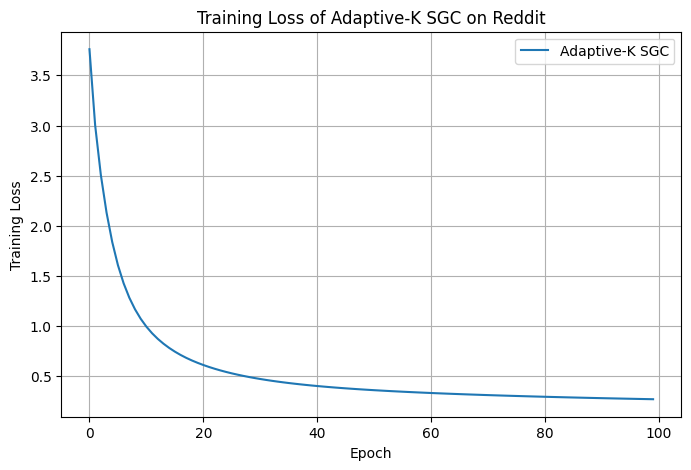

In [ ]:
# 10. Training Loss Plot

plt.figure(figsize=(8, 5))

plt.plot(
    adaptive_result["train_losses"],
    label="Adaptive-K SGC"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss of Adaptive-K SGC on Reddit")
plt.legend()
plt.grid(True)
plt.show()

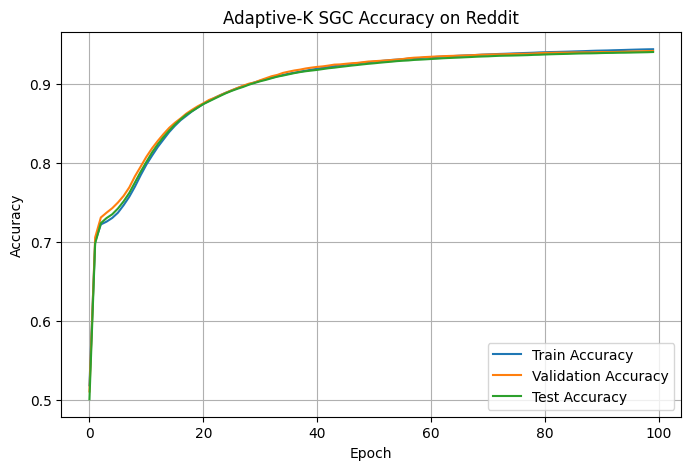

In [ ]:
# 11. Accuracy Plot

plt.figure(figsize=(8, 5))

plt.plot(
    adaptive_result["train_accs"],
    label="Train Accuracy"
)

plt.plot(
    adaptive_result["val_accs"],
    label="Validation Accuracy"
)

plt.plot(
    adaptive_result["test_accs"],
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Adaptive-K SGC Accuracy on Reddit")
plt.legend()
plt.grid(True)
plt.show()

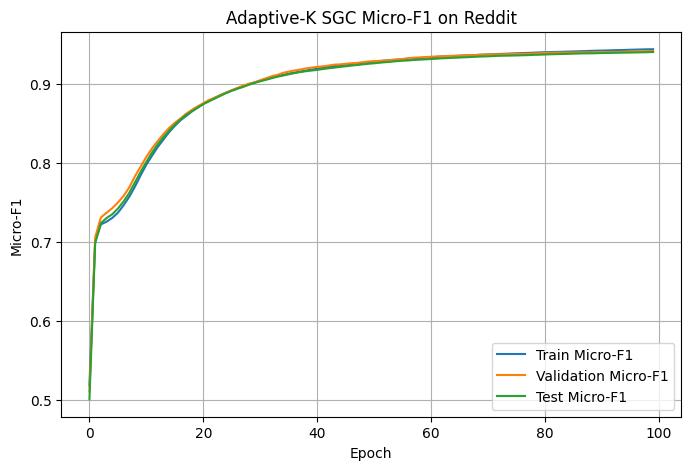

In [ ]:
# 12. Micro-F1 Plot

plt.figure(figsize=(8, 5))

plt.plot(
    adaptive_result["train_micro_f1s"],
    label="Train Micro-F1"
)

plt.plot(
    adaptive_result["val_micro_f1s"],
    label="Validation Micro-F1"
)

plt.plot(
    adaptive_result["test_micro_f1s"],
    label="Test Micro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Micro-F1")
plt.title("Adaptive-K SGC Micro-F1 on Reddit")
plt.legend()
plt.grid(True)
plt.show()

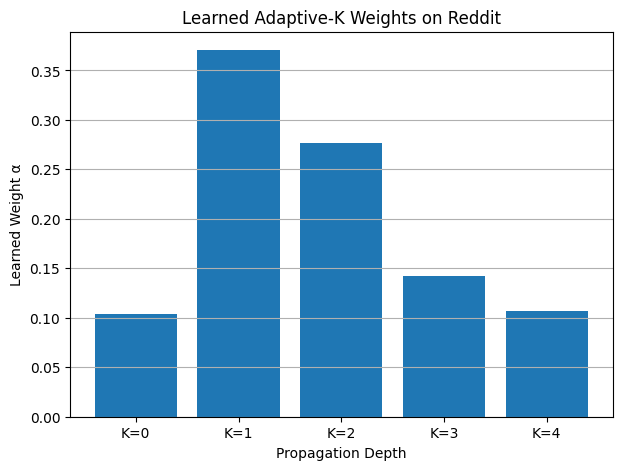

Best alpha weights:
K=0: 0.1043
K=1: 0.3706
K=2: 0.2762
K=3: 0.1426
K=4: 0.1064


In [ ]:
# 13. Learned Alpha Weights

best_alpha = adaptive_result["best_alpha"]

plt.figure(figsize=(7, 5))

plt.bar(
    [f"K={k}" for k in range(K_MAX + 1)],
    best_alpha
)

plt.xlabel("Propagation Depth")
plt.ylabel("Learned Weight α")
plt.title("Learned Adaptive-K Weights on Reddit")
plt.grid(axis="y")
plt.show()

print("Best alpha weights:")
for k, a in enumerate(best_alpha):
    print(f"K={k}: {a:.4f}")

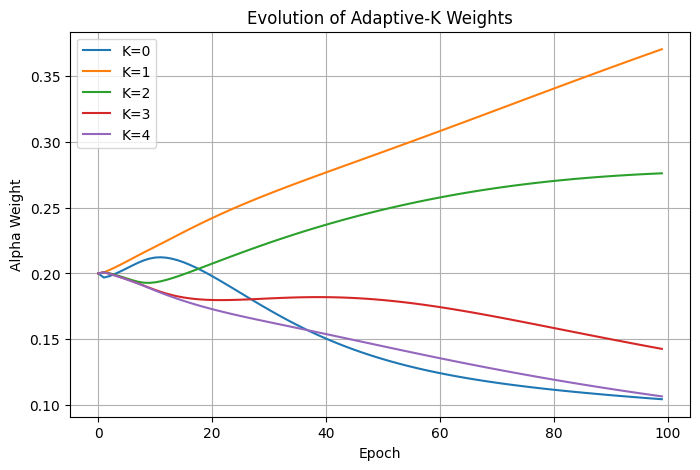

In [ ]:
# 14. Alpha Evolution Plot

alpha_history = np.array(adaptive_result["alpha_history"])

plt.figure(figsize=(8, 5))

for k in range(K_MAX + 1):
    plt.plot(
        alpha_history[:, k],
        label=f"K={k}"
    )

plt.xlabel("Epoch")
plt.ylabel("Alpha Weight")
plt.title("Evolution of Adaptive-K Weights")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 15. Final Interpretation Helper

print("Final Summary")
print("-------------")
print(f"Best Validation Accuracy: {adaptive_result['best_val_acc']:.4f}")
print(f"Best Test Accuracy: {adaptive_result['best_test_acc']:.4f}")
print(f"Best Validation Micro-F1: {adaptive_result['best_val_micro_f1']:.4f}")
print(f"Best Test Micro-F1: {adaptive_result['best_test_micro_f1']:.4f}")
print(f"Best Epoch: {adaptive_result['best_epoch']}")
print(f"Precompute Time: {precompute_time:.2f} seconds")
print(f"Training Time: {adaptive_result['training_time']:.2f} seconds")
print(f"Total Time: {precompute_time + adaptive_result['training_time']:.2f} seconds")
print("Learned alpha weights:")

for k, a in enumerate(adaptive_result["best_alpha"]):
    print(f"  K={k}: {a:.4f}")

Final Summary
-------------
Best Validation Accuracy: 0.9420
Best Test Accuracy: 0.9407
Best Validation Micro-F1: 0.9420
Best Test Micro-F1: 0.9407
Best Epoch: 100
Precompute Time: 14.04 seconds
Training Time: 52.47 seconds
Total Time: 66.51 seconds
Learned alpha weights:
  K=0: 0.1043
  K=1: 0.3706
  K=2: 0.2762
  K=3: 0.1426
  K=4: 0.1064
